# Time Series Analysis — SARIMAX
Model
## RELIANCE.NS | 2005 | With Stationarity Phase

**Pipeline:**
1. Data Collection (yfinance)
2. **Stationarity Testing (ADF Test)**
3. **Differencing + ACF/PACF Analysis**
4. Normalization (MinMaxScaler on stationary data)
5. Train/Test Split
6. AR Model Grid Search
7. Best Model Evaluation
8. Inverse Transform → Original Price Scale
9. Forecasting

---
## Step 1: Install & Import Libraries

In [1]:
!pip install yfinance statsmodels scikit-learn matplotlib --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

print("All libraries imported successfully!")

All libraries imported successfully!


---
## Step 2: Download Stock Data

In [3]:
ticker = "RELIANCE.NS"
year = 2005
start_date = f"{year}-01-01"
end_date   = f"{year}-12-31"

stk_data = yf.download(ticker, start=start_date, end=end_date, progress=False)

if stk_data.empty:
    print(f"No data available for {ticker} in {year}.")
else:
    stk_data = stk_data[["Open", "High", "Low", "Close"]]
    print(f"OHLC data for {ticker} in {year}:")
    print(stk_data.head())
    print(f"\nShape: {stk_data.shape}")

OHLC data for RELIANCE.NS in 2005:
Price             Open        High         Low       Close
Ticker     RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS
Date                                                      
2005-01-03   32.366290   32.702315   32.030265   32.633308
2005-01-04   33.002333   33.002333   31.778247   31.877254
2005-01-05   31.562233   32.009265   30.971192   31.799248
2005-01-06   31.682249   32.192286   31.337223   31.574244
2005-01-07   32.102282   32.864335   31.655251   32.537312

Shape: (250, 4)


In [4]:
column = "Close"
close_prices = stk_data[[column]].copy()
close_prices.head()

Price,Close
Ticker,RELIANCE.NS
Date,
2005-01-03,32.633308
2005-01-04,31.877254
2005-01-05,31.799248
2005-01-06,31.574244
2005-01-07,32.537312


In [5]:
from sklearn.preprocessing import MinMaxScaler
Ms=MinMaxScaler()
data1=Ms.fit_transform(stk_data[["Close"]])
print("Len:",data1.shape)

Len: (250, 1)


# Train / Test Split (80/20)

In [6]:
training_size = round(len(data1) * 0.80)
print(f"Training size : {training_size}")
print(f"Test size     : {len(data1) - training_size}")

X_train = data1[:training_size]
X_test  = data1[training_size:]
y_train = data1[:training_size]
y_test  = data1[training_size:]

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")

last_train_price = float(close_prices[column].iloc[training_size])
print(f"\nLast original close price at train boundary: {last_train_price:.2f} INR")

Training size : 200
Test size     : 50

X_train shape: (200, 1)
X_test shape : (50, 1)

Last original close price at train boundary: 45.94 INR


In [7]:
"""from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(data1, order=(1,1,1))#Autoregressive Integrated Moving Average (ARIMA)
model_fit = model.fit()
# make prediction
y_pred= model_fit.predict(len(stk_data), len(stk_data)-1)
print(y_pred)
from stockFunctions import rmsemape
rmsemape(stkk,predicted_stock_price_test_oriP["Open"])"""

'from statsmodels.tsa.arima.model import ARIMA\nmodel = ARIMA(data1, order=(1,1,1))#Autoregressive Integrated Moving Average (ARIMA)\nmodel_fit = model.fit()\n# make prediction\ny_pred= model_fit.predict(len(stk_data), len(stk_data)-1)\nprint(y_pred)\nfrom stockFunctions import rmsemape\nrmsemape(stkk,predicted_stock_price_test_oriP["Open"])'

In [8]:
from sklearn.metrics import mean_squared_error
from stockFunctions import rmsemape
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Trend options
trends = ['n','t','c','ct']

# Non-seasonal orders (p,d,q)
orders = [(1,1,1), (2,1,1), (2,1,2)]

# Seasonal orders (P,D,Q,s)
seasonal_orders = [(1,1,1,7), (1,1,1,12)]   # change s if needed

for order in orders:
    
    for seasonal in seasonal_orders:
        
        for td in trends:
            
            try:
                # Build SARIMAX model
                model = SARIMAX(
                    X_train,
                    order=order,
                    seasonal_order=seasonal,
                    trend=td
                )
                
                model_fit = model.fit(disp=False)
                
                # Forecast test set
                y_pred = model_fit.forecast(steps=len(y_test))
                
                print(f"Order = {order} | Seasonal = {seasonal} | Trend = {td}")
                rmsemape(y_test, y_pred)
                print("***********")
                
            except:
                continue

C:\Users\gnana\anaconda3\envs\myenv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Order = (1, 1, 1) | Seasonal = (1, 1, 1, 7) | Trend = n
RMSE-Testset: 0.015928623058508007
MAPE-Testset: 0.09391403565408676
***********
Order = (1, 1, 1) | Seasonal = (1, 1, 1, 7) | Trend = t
RMSE-Testset: 0.095010305678293
MAPE-Testset: 0.5478438166885897
***********
Order = (1, 1, 1) | Seasonal = (1, 1, 1, 7) | Trend = c
RMSE-Testset: 0.027453612749335107
MAPE-Testset: 0.18397373694333286
***********


C:\Users\gnana\anaconda3\envs\myenv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Order = (1, 1, 1) | Seasonal = (1, 1, 1, 7) | Trend = ct
RMSE-Testset: 0.1634701831505037
MAPE-Testset: 0.9388996247438302
***********


C:\Users\gnana\anaconda3\envs\myenv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


...

Order = (2, 1, 1) | Seasonal = (1, 1, 1, 12) | Trend = c
RMSE-Testset: 0.022285131617494812
MAPE-Testset: 0.10282086318809398
***********
Order = (2, 1, 1) | Seasonal = (1, 1, 1, 12) | Trend = ct
RMSE-Testset: 0.14541749784947736
MAPE-Testset: 0.8478760215387883
***********
Order = (2, 1, 2) | Seasonal = (1, 1, 1, 7) | Trend = n
RMSE-Testset: 0.015291064604060352
MAPE-Testset: 0.08855192888605108
***********
Order = (2, 1, 2) | Seasonal = (1, 1, 1, 7) | Trend = t
RMSE-Testset: 0.11268939358837726
MAPE-Testset: 0.6631012444449508
***********


C:\Users\gnana\anaconda3\envs\myenv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Order = (2, 1, 2) | Seasonal = (1, 1, 1, 7) | Trend = c
RMSE-Testset: 0.03626721766843434
MAPE-Testset: 0.2453504018927596
***********
Order = (2, 1, 2) | Seasonal = (1, 1, 1, 7) | Trend = ct
RMSE-Testset: 0.18295055156111506
MAPE-Testset: 1.060111561422258
***********
Order = (2, 1, 2) | Seasonal = (1, 1, 1, 12) | Trend = n
RMSE-Testset: 0.017751614693587166
MAPE-Testset: 0.09180770147400168
***********


C:\Users\gnana\anaconda3\envs\myenv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Order = (2, 1, 2) | Seasonal = (1, 1, 1, 12) | Trend = t
RMSE-Testset: 0.05277839960069577
MAPE-Testset: 0.30605082081439955
***********
Order = (2, 1, 2) | Seasonal = (1, 1, 1, 12) | Trend = c
RMSE-Testset: 0.030726688093645992
MAPE-Testset: 0.196601776205057
***********
Order = (2, 1, 2) | Seasonal = (1, 1, 1, 12) | Trend = ct
RMSE-Testset: 0.2299384863182159
MAPE-Testset: 1.3568916291716642
***********


In [13]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

best_model = SARIMAX(
    X_train,
    order=(2,1,2),
    seasonal_order=(0,0,0,0),   # No seasonality
    trend='t'
)

best_model_fit = best_model.fit(disp=False)

print(best_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  200
Model:               SARIMAX(2, 1, 2)   Log Likelihood                 250.611
Date:                Thu, 05 Mar 2026   AIC                           -489.222
Time:                        20:00:08   BIC                           -469.462
Sample:                             0   HQIC                          -481.225
                                - 200                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
drift       4.419e-06      0.000      0.013      0.990      -0.001       0.001
ar.L1         -0.7962    131.521     -0.006      0.995    -258.572     256.980
ar.L2         -0.0140      2.287     -0.006      0.9

C:\Users\gnana\anaconda3\envs\myenv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [14]:

# 1️⃣ Forecast
y_pred_scaled = best_model_fit.forecast(steps=len(X_test))
# 2️⃣ Inverse both
y_pred_original = Ms.inverse_transform(
    y_pred_scaled.reshape(-1,1)
).flatten()

X_test_original = Ms.inverse_transform(
    X_test.reshape(-1,1)
).flatten()

# 3️⃣ Evaluate
rmsemape(X_test_original, y_pred_original)

RMSE-Testset: 1.4507052523591561
MAPE-Testset: 0.025765467918267


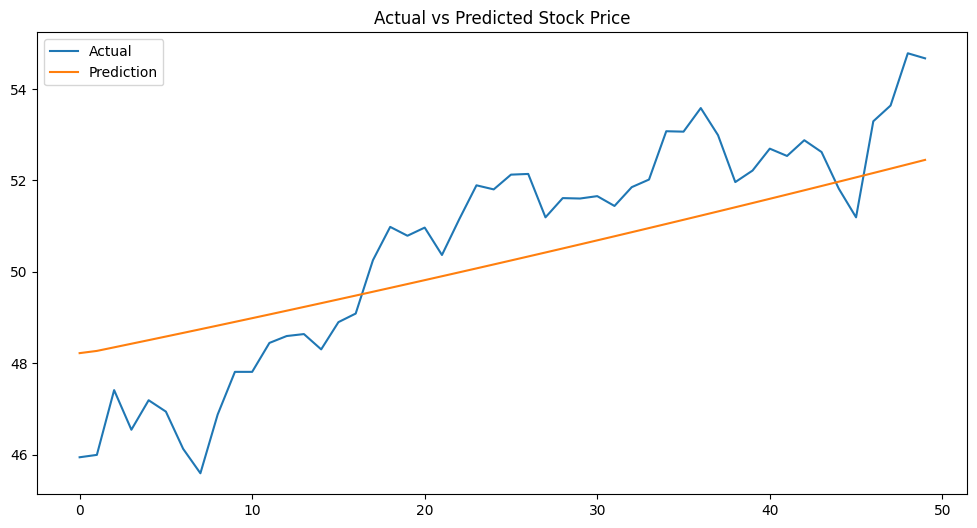

In [15]:
plt.figure(figsize=(12,6))
plt.plot(X_test_original, label="Actual")
plt.plot(y_pred_original, label="Prediction")
plt.legend()
plt.title("Actual vs Predicted Stock Price")
plt.show()

In [16]:

future_scaled = best_model_fit.forecast(steps=3)
future_original = Ms.inverse_transform(
    future_scaled.reshape(-1,1)
).flatten()

print(future_original)

[48.2213235  48.27003109 48.34810507]
